# Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv("Telco-Customer-Churn.csv")
print(data.head())
print(data.shape) 

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# null values

In [2]:
print(data.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [3]:
print(data.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


# Data information

In [4]:
print("Data Information: ")
data.info()
print("=================================")
print("Data Describe: ")
print(data.describe())
print("=================================")
data["Churn"].value_counts()

Data Information: 
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Drop useless columns

In [5]:
data = data.drop(columns=['customerID'])
print(data.shape)

(7043, 20)


In [6]:
# converting total charges into float dtype
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors ="coerce")

In [7]:
print(data.isna().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [8]:
# filling null values with (MonthlyChrges x tenure)

data["TotalCharges"] = data["TotalCharges"].fillna(data["MonthlyCharges"] * data["tenure"])

In [9]:
print(data.isna().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Correlation between target and Features

Correlation of Target with numerical features

In [10]:
copy = data.copy()

print("Data Information: ")
copy.info()

Data Information: 
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   

In [11]:
# Mostly features are present in object datatype
# conversion is required for plotting correlation matrix

In [12]:
# binary columns
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

for col in binary_cols:
    copy[col] = copy[col].map({"No": 0, "Yes": 1})

# copy["OnlineSecurity"] = copy["OnlineSecurity"].map({"No": 0, "Yes":1})
# copy["OnlineBackup"] = copy["OnlineBackup"].map({"No": 0, "Yes":1})
# copy["DeviceProtection"] = copy["DeviceProtection"].map({"No": 0, "Yes":1})
# copy["TechSupport"] = copy["TechSupport"].map({"No": 0, "Yes":1})
# copy["StreamingTV"] = copy["StreamingTV"].map({"No": 0, "Yes":1})
# copy["TechSupport"] = copy["TechSupport"].map({"No": 0, "Yes":1})
# copy["MultipleLines"] = copy["MultipleLines"].map({"No phone service": 0, "No": 1, "Yes":2})
# copy["StreamingMovies"] = copy["StreamingMovies"].map({"No": 0, "Yes":1})

In [13]:
cor = copy.corr(numeric_only = True)
print(cor['Churn'].sort_values(ascending=False))

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.198324
tenure             -0.352229
Name: Churn, dtype: float64


#  Correlation with categorial values

In [14]:
print("Data Information: ")
copy.info()

Data Information: 
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   

In [15]:
pd.crosstab(data['InternetService'], data['Churn'], normalize="index")*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [16]:
# Customer using Fiber optic internet have the highest churn rate (~41%). 
# This suggests these customers may be less satisfied or may belong to plans with higher prices.
#  This feature is likely to be important for predicting churn.

In [17]:
pd.crosstab(data['PaymentMethod'], data['Churn'], normalize="index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [18]:
# Customer with payment method Electronic check have highest churn rate(~45.28%)
# This suggests that customers paying through Electric check is more likely to leave the service than customers using other payment methods.

In [19]:
pd.crosstab(data['Contract'], data['Churn'], normalize="index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [20]:
# Customers with month-to-month contracts have the highest churn rate (~42.7%).
# Customers with one-year contracts have a much lower churn rate (~11.3%).
# Customers with two-year contracts have the lowest churn rate (~2.8%).
# This indicates that longer contracts significantly reduce customer churn. Contract type is likely one of the strongest predictors of churn.

<Axes: xlabel='Churn', ylabel='tenure'>

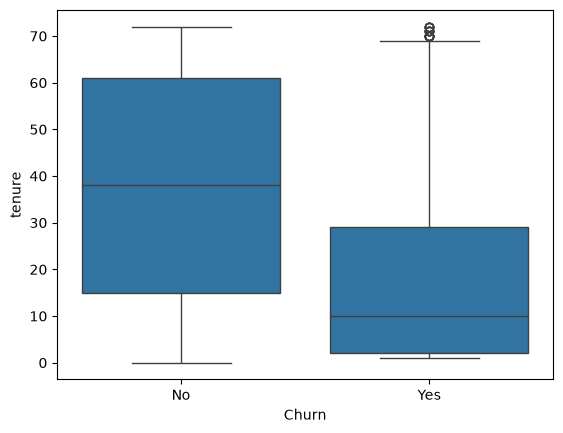

In [21]:
import seaborn as sns

sns.boxplot(x="Churn", y="tenure", data=data)

In [22]:
# Customers with shorter tenure are much more likely to churn. 
# The median tenure of churned customers is significantly lower than that of retained customers. 
# This suggests that new customers are at a higher risk of leaving, making tenure one of the strongest predictors of churn.

In [23]:
pd.crosstab(data['TechSupport'], data['Churn'], normalize="index")*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [24]:
pd.crosstab(data['OnlineSecurity'], data['Churn'], normalize="index")*100 

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [25]:
pd.crosstab(data['OnlineBackup'], data['Churn'], normalize="index")*100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [26]:
pd.crosstab(data['DeviceProtection'], data['Churn'], normalize="index")*100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [27]:
# Lack of Tech Support, Online Support, Backup and device Protection is associated with much higher churn.

In [28]:
pd.crosstab(data['StreamingTV'], data['Churn'], normalize="index")*100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [29]:
pd.crosstab(data['StreamingMovies'], data['Churn'], normalize="index")*100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [30]:
pd.crosstab(data['gender'], data['Churn'], normalize="index")*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [31]:
# Male and Female customers have nearly identical churn rates. 
# Therefore, gender is not a strong indicator of customer churn

In [32]:
data = data.drop(columns=['gender'])

In [33]:
pd.crosstab(data['SeniorCitizen'], data['Churn'], normalize="index")*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [34]:
# Senior Citizens have a significantly higher churn rate (41.7%) compare to non-senior citizens (23.6%). 
# This feature is likely to be important for churn prediction

In [35]:
# Understanding target

copy["Churn"].value_counts(normalize=True)*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [36]:
# Churn rate is 26%

# Relationship between different features

In [37]:
pd.crosstab([data["Contract"], data["InternetService"]], data["Churn"], normalize= "index") * 100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [38]:
# Month-to-month contract with fiber optic service have higher churned rate
# This suggest that they are less satisfy by the service

In [39]:
pd.crosstab([data["TechSupport"], data["InternetService"]], data["Churn"], normalize="index")*100

Churn                                       No        Yes
TechSupport         InternetService                      
No                  DSL              72.244570  27.755430
                    Fiber optic      50.627803  49.372197
No internet service No               92.595020   7.404980
Yes                 DSL              90.322581   9.677419
                    Fiber optic      77.367206  22.632794

# Droping useless columns

In [40]:
# columns to be removed
remove = ["DeviceProtection", "PhoneService", "Partner", "StreamingTV", "OnlineBackup"]

# removing less important features
data = data.drop(columns=remove)

#  Feature Engineering

In [41]:
copy["HighRisk"] = ((copy["InternetService"] == "Fiber optic") & (copy["PaymentMethod"] == "Electronic check")).astype(int)

copy[["HighRisk","PaymentMethod","InternetService"]].head(10)

,HighRisk,PaymentMethod,InternetService
0,0,Electronic check,DSL
1,0,Mailed check,DSL
2,0,Mailed check,DSL
3,0,Bank transfer (automatic),DSL
4,1,Electronic check,Fiber optic
5,1,Electronic check,Fiber optic
6,0,Credit card (automatic),Fiber optic
7,0,Mailed check,DSL
8,1,Electronic check,Fiber optic
9,0,Bank transfer (automatic),DSL


In [42]:
col = ["OnlineSecurity","TechSupport"]
copy["ProtectionScore"] = (copy[col] == "Yes").astype(int).sum(axis=1)

In [43]:
cor_mat = copy.corr(numeric_only = True)
cor_mat["Churn"].sort_values(ascending=False)

Churn               1.000000
HighRisk            0.327100
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.198324
ProtectionScore    -0.204042
tenure             -0.352229
Name: Churn, dtype: float64

In [44]:
pd.crosstab(copy["ProtectionScore"], copy["Churn"], normalize="index")*100

Churn,0,1
ProtectionScore,,
0,66.584947,33.415053
1,78.176944,21.823056
2,90.991811,9.008189


In [45]:
copy[copy["ProtectionScore"] == 1].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HighRisk,ProtectionScore
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,No,No,One year,0,Mailed check,56.95,1889.50,0,0,1
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0,1
7,Female,0,0,0,10,0,No phone service,DSL,Yes,No,...,No,No,Month-to-month,0,Mailed check,29.75,301.90,0,0,1
8,Female,0,1,0,28,1,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,1,1
9,Male,0,0,1,62,1,No,DSL,Yes,Yes,...,No,No,One year,0,Bank transfer (automatic),56.15,3487.95,0,0,1


In [46]:
copy["IsNewCustomer"] = data["tenure"]<12

stream =["StreamingMovies"]
copy["StreamingScore"] = (copy[stream] == "Yes").astype(int).sum(axis=1)

In [47]:
cor_mat2 = copy.corr(numeric_only = True)
cor_mat2["Churn"].sort_values(ascending=False)

Churn               1.000000
HighRisk            0.327100
IsNewCustomer       0.317666
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingScore      0.061382
PhoneService        0.011942
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.198324
ProtectionScore    -0.204042
tenure             -0.352229
Name: Churn, dtype: float64

# Feature engineering Class for Pipeline

In [48]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self

    def transform(self, x):
        x = x.copy()

        # HighRisk feature
        x["HighRisk"] = ((x["InternetService"] == "Fiber optic") & (x["PaymentMethod"] == "Electronic check")).astype(int)

        # Has any kind of Protecteion
        col = ["OnlineSecurity","TechSupport"]
        x["ProtectionScore"] = (x[col] == "Yes").astype(int).sum(axis=1)

        # IsNewCustomer feature
        x["IsNewCustomer"] = ((x["tenure"]<12).astype(int))

        # HasStreaming feature
        stream =["StreamingMovies"]
        x["StreamingScore"] = (x[stream] == "Yes").astype(int).sum(axis=1)

        # mapping categorial features into numerical
        mapping={"Yes": 1,
                  "No": 0,
                  "No internet service": 0,
                  "No phone service": 0}
        
        cols = ["TechSuppor",
                "OnlineSecurity",
                "StreamingMovies",
                "MultipleLines",
                "Dependents",
                "PaperlessBilling",
               "Churn"]

        for col in cols:
            x[col]= x[col].map(mapping)

        # remove temporary columns
        # x.drop(columns=['StreamingTV', 'StreamingMovies','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'], inplace=True)

        return x

# Encoding

In [49]:
# different columns for different encoding

# columns for OneHotEncoding
OneHot_col = ["PaymentMethod", "InternetService","Contract"]

# columns for scalling
num_cols=["MonthlyCharges", "TotalCharges", "tenure"]

In [50]:
# preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[("onehot",OneHotEncoder(handle_unknown="ignore"), OneHot_col)], remainder="passthrough")

preprocessor_scaler = ColumnTransformer(
    transformers=[("onehot", OneHotEncoder(handle_unknown="ignore"), OneHot_col),
                  ("scale", StandardScaler(), num_cols)], remainder="passthrough")

# Split Dataset

In [51]:
from sklearn.model_selection import train_test_split

# mapping target
data['Churn'] = data['Churn'].map({"Yes": 1, "No": 0})

x = data.drop(columns='Churn')
y = data['Churn']

x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

# Logistic Regression Model

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from feature_engineering import FeatureEngineering

pipeline_lr = Pipeline([("FeatureEngineering", (FeatureEngineering())),
                        ("Preprocessor", preprocessor_scaler),
                        ("model", LogisticRegression())])

# training model
pipeline_lr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('FeatureEngineering', ...), ('Preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.

In [53]:
fe = FeatureEngineering()
temp = fe.transform(x_train.copy())
print(temp.columns.tolist())
print(temp.isna().sum())

['SeniorCitizen', 'Dependents', 'tenure', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'HighRisk', 'ProtectionScore', 'IsNewCustomer', 'StreamingScore']
SeniorCitizen       0
Dependents          0
tenure              0
MultipleLines       0
InternetService     0
OnlineSecurity      0
TechSupport         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
HighRisk            0
ProtectionScore     0
IsNewCustomer       0
StreamingScore      0
dtype: int64


In [54]:
# prediction
pred_lr = pipeline_lr.predict(x_test)

# evaluation
from sklearn.metrics import ( accuracy_score, recall_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print("Recall :", recall_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))
print("Accuracy Score :", accuracy_score(y_test, pred_lr))
print("ROC AUC :", roc_auc_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Recall : 0.5495978552278821
Precision : 0.6765676567656765
F1 Score : 0.606508875739645
Accuracy Score : 0.8112136266855926
ROC AUC : 0.7275016303166437
[[938  98]
 [168 205]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# Random Forest Classifier Model

In [55]:
from sklearn.ensemble import RandomForestClassifier
from feature_engineering import FeatureEngineering

pipeline_rf = Pipeline([("FeatureEngineering", (FeatureEngineering())),
                        ("Preprocessor", preprocessor),
                        ("model", RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42, class_weight="balanced"))])

# training model
pipeline_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('FeatureEngineering', ...), ('Preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using 

In [56]:
pred_rf2 = pipeline_rf.predict(x_test)

# evaluation
from sklearn.metrics import ( accuracy_score, recall_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print("Recall :", recall_score(y_test, pred_rf2))
print("Precision :", precision_score(y_test, pred_rf2))
print("F1 Score :", f1_score(y_test, pred_rf2))
print("Accuracy Score :", accuracy_score(y_test, pred_rf2))
print("ROC AUC :", roc_auc_score(y_test, pred_rf2))
print(confusion_matrix(y_test, pred_rf2))
print(classification_report(y_test, pred_rf2))

Recall : 0.8284182305630027
Precision : 0.5392670157068062
F1 Score : 0.653276955602537
Accuracy Score : 0.7672107877927609
ROC AUC : 0.786795987868374
[[772 264]
 [ 64 309]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [57]:
y_prob = pipeline_rf.predict_proba(x_test)[:,1]

# setting thresholf
threshold=0.60

pred_rf = (y_prob>=threshold).astype(int)

# evaluation
from sklearn.metrics import ( accuracy_score, recall_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print("Recall :", recall_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))
print("Accuracy Score :", accuracy_score(y_test, pred_rf))
print("ROC AUC :", roc_auc_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Recall : 0.7265415549597856
Precision : 0.620137299771167
F1 Score : 0.6691358024691358
Accuracy Score : 0.8097941802696949
ROC AUC : 0.7831549473640627
[[870 166]
 [102 271]]
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1036
           1       0.62      0.73      0.67       373

    accuracy                           0.81      1409
   macro avg       0.76      0.78      0.77      1409
weighted avg       0.82      0.81      0.81      1409



In [58]:
# Since missing churn customers is costly, I evaluated different probability thresholds.
# A threshold of 0.6 improved precision from approximately 0.54 to 0.62 
# while maintaining recall at approximately 0.73, resulting in the highest F1 score.

# Hyperparameter Tuning for Random forest Model

In [59]:
from sklearn.model_selection import RandomizedSearchCV

param_grid ={"model__n_estimators": [100,200,300,400],
             "model__max_depth": [5,8,9,15,None],
             "model__min_samples_split": [2,5,8,10],
             "model__min_samples_leaf": [1,2,7,5,6],
             "model__max_features":["sqrt", "log2"]}

search = RandomizedSearchCV(pipeline_rf,
                            param_distributions=param_grid,
                            n_iter=25,
                            scoring='f1',
                            cv=5,
                            random_state=42,n_jobs=-1)

search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 8, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSea

In [60]:
print(search.best_params_)
print(search.best_score_)

{'model__n_estimators': 100, 'model__min_samples_split': 8, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 9}
0.6342805716142674


In [61]:
best_model = search.best_estimator_
pred = best_model.predict(x_test)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Recall :", recall_score(y_test, pred))
print("Precision :", precision_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("Accuracy :", accuracy_score(y_test, pred))
print("ROC AUC :", roc_auc_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Recall : 0.8096514745308311
Precision : 0.5252173913043479
F1 Score : 0.6371308016877637
Accuracy : 0.7558552164655784
ROC AUC : 0.7730689805086588
[[763 273]
 [ 71 302]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1036
           1       0.53      0.81      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



# Gradient Boosting Model

In [63]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([("FeatureEngineering", (FeatureEngineering())),
                        ("Preprocessor", preprocessor),
                        ("model", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42))])

# training model
pipeline_gb.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('FeatureEngineering', ...), ('Preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using 

In [64]:
pred_gb = pipeline_gb.predict(x_test)

# evaluation
from sklearn.metrics import ( accuracy_score, recall_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print("Recall :", recall_score(y_test, pred_gb))
print("Precision :", precision_score(y_test, pred_gb))
print("F1 Score :", f1_score(y_test, pred_gb))
print("Accuracy Score :", accuracy_score(y_test, pred_gb))
print("ROC AUC :", roc_auc_score(y_test, pred_gb))
print(confusion_matrix(y_test, pred_gb))
print(classification_report(y_test, pred_gb))

Recall : 0.5576407506702413
Precision : 0.6688102893890675
F1 Score : 0.6081871345029239
Accuracy Score : 0.8097941802696949
ROC AUC : 0.729109950624696
[[933 103]
 [165 208]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# XGBoost Model

In [65]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([("FeatureEngineering", (FeatureEngineering())),
                        ("Preprocessor", preprocessor),
                        ("model", XGBClassifier(random_state=42, eval_metric="logloss"))])

# training model
pipeline_gb.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('FeatureEngineering', ...), ('Preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using 

In [66]:
pred_xgb = pipeline_gb.predict(x_test)

# evaluation
from sklearn.metrics import ( accuracy_score, recall_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)

print("Recall :", recall_score(y_test, pred_xgb))
print("Precision :", precision_score(y_test, pred_xgb))
print("F1 Score :", f1_score(y_test, pred_xgb))
print("Accuracy Score :", accuracy_score(y_test, pred_xgb))
print("ROC AUC :", roc_auc_score(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

Recall : 0.5576407506702413
Precision : 0.6688102893890675
F1 Score : 0.6081871345029239
Accuracy Score : 0.8097941802696949
ROC AUC : 0.729109950624696
[[933 103]
 [165 208]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# Hyperparameter tuning for XGBoost

In [67]:
from sklearn.model_selection import RandomizedSearchCV

param_grid2 = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

search2 = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_grid2,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search2.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedS

In [68]:
print(search2.best_params_)
print(search2.best_score_)

{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
0.5757359099600554


# Feature Importance

In [69]:
# preprocessor = pipeline_rf.named_steps["Preprocessor"]

feature_names = pipeline_rf.named_steps["Preprocessor"].get_feature_names_out()

importances = pipeline_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"Feature": feature_names,
                                      "Importance": importances})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                                            Feature  Importance
7                   onehot__Contract_Month-to-month    0.183637
12                                remainder__tenure    0.140849
9                         onehot__Contract_Two year    0.097371
18                        remainder__MonthlyCharges    0.086112
19                          remainder__TotalCharges    0.084774
5               onehot__InternetService_Fiber optic    0.072333
22                         remainder__IsNewCustomer    0.050971
20                              remainder__HighRisk    0.045860
2            onehot__PaymentMethod_Electronic check    0.040802
6                        onehot__InternetService_No    0.039440
21                       remainder__ProtectionScore    0.025026
8                         onehot__Contract_One year    0.023840
4                       onehot__InternetService_DSL    0.015555
17                      remainder__PaperlessBilling    0.015071
14                        remainder__Onl

# Save Pipeline

In [ ]:
# Saving the final optimized pipeline for deployment.
# Selected based on the best balance of Precision, Recall, and F1 Score.

In [70]:
import joblib

joblib.dump(pipeline_rf, "churn_pipeline.pkl")
joblib.dump(0.6,"threshold.pkl")

['threshold.pkl']